## 분석해야 할 통계 데이터 목록

현재 프로젝트에서 수정에 영향을 줄 수 있는 통계 데이터는 다음과 같다.

| 데이터 | 주로 반영할 노트북 | 활용 목적 |
|---|---|---|
| 방문자 수 추이 | 모델 2 | 남양주시 관광 수요 규모 반영 |
| 방문자 증감률 | 모델 2 | 최근 관광 수요 상승/하락 반영 |
| 거리별 방문자 분포 | 모델 3 | 추천 거리 제한 및 거리 점수 보정 |
| 방문자 거주지 분포 | 모델 2, 모델 3 | 외지인/현지인 중심 추천 방향 설정 |
| 방문자 성·연령별 분포 | 모델 3 | 동반 유형 및 사용자 조건별 추천 가중치 조정 |
| 외국인 방문 현황 | 모델 2, 모델 3 | 외국인 대응 관광지 또는 다국어 서비스 확장 근거 |
| 평균 체류시간 추이 | 모델 2, 모델 3 | 장시간 체류형 관광지/코스 추천 반영 |
| 평균 숙박일 | 모델 2, 모델 3 | 숙박 기반 여행 코스 추천 반영 |
| 숙박방문자 비율 추이 | 모델 2, 모델 3 | 당일치기/숙박형 추천 전략 구분 |
| 숙박 유형별 방문자 비율 | 모델 3 | 숙소 유형별 출발 추천 시나리오 구성 |
| 숙박 목적지 검색건수 | 모델 3 | 숙소 기반 추천 출발점 설정 근거 |
| 숙박 목적지 유입 지역 분포 | 모델 3 | 외부 유입 관광객 특성 반영 |
| 관광소비 추이 | 모델 2 | 소비 규모 기반 관광 수요 점수 반영 |
| 지역화폐 관광소비 추이 | 모델 2 | 지역 내 소비 활성도 반영 |
| 내비게이션 목적지 유형별 검색량 | 모델 2, 모델 3 | 관광지 유형별 관심도 및 테마 가중치 반영 |
| 내비게이션 검색 유형 분포 | 모델 2, 모델 3 | 음식/숙박/관광지 등 관심 유형 분포 반영 |
| 현지인·외지인 관심지점 비교 | 모델 2, 모델 3 | 현지인/외지인 추천 전략 분리 |

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.preprocessing import MinMaxScaler

font_candidates = ['NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR', 'AppleGothic', 'Malgun Gothic']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font in font_candidates:
    if font in installed_fonts:
        plt.rcParams['font.family'] = font
        break

plt.rcParams['axes.unicode_minus'] = False
print('사용 폰트:', plt.rcParams['font.family'])

사용 폰트: ['AppleGothic']


### 남양주시 관광 수요 규모 반영

방문자 수 추이 데이터는 남양주시의 월별 관광 수요 규모와 전년 동월 대비 변화율을 파악하기 위해 사용한다.   
이를 통해 관광 수요가 높은 시기와 낮은 시기를 구분하고, 추천 점수 예측 모델에서 월별 관광 수요를 보정하는 변수로 활용한다.

본 분석에서는 방문자 수, 전년 동월 방문자 수, 방문자 수 증감률을 기반으로 월별 관광 수요 흐름을 분석하고, 최종적으로 모델 입력에 사용할 수 있는 `visitor_demand_score`를 생성한다.

#### 분석 진행 방식

1. 데이터 수집
2. 데이터 전처리
   1. 기준년월 전처리
   2. 연도, 월, 분기 컬럼 생성
3. 데이터 분석
   1. 기본 통계 분석
   2. 전년 동월 대비 증감률 분석
   3. 분기별 방문자 수 분석
4. 데이터 시각화
   1. 월별 방문자 수 선그래프: 월별 관광 수요 흐름 확인
   2. 방문자 수와 전년 동월 방문자 수 비교 그래프: 전년 대비 수요 변화 확인
   3. 증감률 그래프: 전년 대비 증가·감소 월 확인
   4. 분기별 방문자 수 막대그래프: 계절 및 분기별 관광 수요 흐름 확인
   5. 월별 관광 수요 점수 선그래프: 모델 2에 반영할 최종 수요 점수 확인

#### 분석 결과 해석

방문자 수 추이 분석 결과, 남양주시의 월별 관광 수요는 일정하지 않고 월별 차이를 보인다. 방문자 수가 높은 월은 남양주시 전체 관광 수요가 상대적으로 큰 시기로 해석할 수 있으며, 방문자 수가 낮은 월은 관광 수요가 상대적으로 약한 시기로 볼 수 있다.

전년 동월 방문자 수와 비교하면 단순 방문자 수 규모뿐만 아니라, 최근 관광 수요가 증가하고 있는지 또는 감소하고 있는지도 함께 확인할 수 있다. 특히 방문자 수 증감률은 전년 같은 월과 비교한 변화 흐름을 보여주기 때문에, 최근 관광 수요의 상승·하락 여부를 판단하는 데 활용할 수 있다.

분기별 방문자 수 분석을 통해서는 특정 계절 또는 분기에 관광 수요가 집중되는지를 확인할 수 있다. 따라서 이 데이터는 관광지 개별 특성을 직접 설명하는 데이터라기보다는, 남양주시 전체 관광 수요 흐름을 나타내는 월별 보정 데이터로 활용하는 것이 적절하다.

#### 모델 반영 방향

방문자 수 추이 데이터는 모델 2의 추천 점수 예측 과정에서 월별 관광 수요 보정 변수로 활용한다. 방문자 수는 관광 수요의 절대 규모를 의미하고, 방문자 수 증감률은 최근 관광 수요의 상승 또는 하락 흐름을 의미한다.

본 분석에서는 방문자 수와 방문자 수 증감률을 각각 0~1 범위로 정규화한 뒤, 두 값을 결합하여 월별 관광 수요 점수인 `visitor_demand_score`를 생성한다.

`visitor_demand_score = visitor_count_scaled × 0.7 + visitor_growth_scaled × 0.3`

이 변수는 특정 월에 남양주시 전체 관광 수요가 얼마나 높은지를 나타내며, 모델 2에서 추천 점수를 보정하는 보조 feature로 사용할 수 있다.

#### 데이터 시각화 결과

##### 1. 월별 방문자 수 추이
<img src="./statistics_outputs/남양주시 관광 수요 규모 반영/01_monthly_visitor_count.png" width="700">

##### 2. 방문자 수와 전년 동월 방문자 수 비교
<img src="./statistics_outputs/남양주시 관광 수요 규모 반영/02_visitor_count_comparison.png" width="700">

##### 3. 전년 동월 대비 방문자 수 증감률
<img src="./statistics_outputs/남양주시 관광 수요 규모 반영/03_visitor_growth_rate.png" width="700">

##### 4. 분기별 방문자 수
<img src="./statistics_outputs/남양주시 관광 수요 규모 반영/04_quarterly_visitor_count.png" width="700">

##### 5. 월별 관광 수요 점수
<img src="./statistics_outputs/남양주시 관광 수요 규모 반영/05_monthly_tourism_demand_score.png" width="700">

In [17]:
# 데이터 수집
data_path = Path("../Data/recommend_score/20260602152817_방문자 수(연인원) 추이.csv")
namyangju_tourism_demand_scale = pd.read_csv(data_path)

display('데이터 크기:', namyangju_tourism_demand_scale.shape)
print('컬럼 목록:')
display(namyangju_tourism_demand_scale.columns.tolist())
print('결측치 개수:')
display(namyangju_tourism_demand_scale.isna().sum())

display(namyangju_tourism_demand_scale.info())

'데이터 크기:'

(12, 4)

컬럼 목록:


['기준년월', '방문자수', '전년동월방문자수', '방문자수증감률']

결측치 개수:


기준년월        0
방문자수        0
전년동월방문자수    0
방문자수증감률     0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   기준년월      12 non-null     int64  
 1   방문자수      12 non-null     float64
 2   전년동월방문자수  12 non-null     float64
 3   방문자수증감률   12 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 512.0 bytes


None

In [ ]:
#  데이터 전처리
namyangju_tourism_demand_scale['기준년월'] = namyangju_tourism_demand_scale['기준년월'].astype(str)
namyangju_tourism_demand_scale['date'] = pd.to_datetime(namyangju_tourism_demand_scale['기준년월'], format='%Y%m')
namyangju_tourism_demand_scale['year'] = namyangju_tourism_demand_scale['date'].dt.year
namyangju_tourism_demand_scale['month'] = namyangju_tourism_demand_scale['date'].dt.month
namyangju_tourism_demand_scale['year_month'] = namyangju_tourism_demand_scale['date'].dt.strftime('%Y-%m')
namyangju_tourism_demand_scale['quarter'] = namyangju_tourism_demand_scale['date'].dt.quarter

# 숫자형 컬럼 정리
numeric_cols = ['방문자수', '전년동월방문자수', '방문자수증감률']
for col in numeric_cols:
    namyangju_tourism_demand_scale[col] = pd.to_numeric(namyangju_tourism_demand_scale[col], errors='coerce')

# 분기별 집계
quarter_df = namyangju_tourism_demand_scale.groupby('quarter', as_index=False).agg(
    방문자수=('방문자수', 'sum'),
    전년동월방문자수=('전년동월방문자수', 'sum')
)

quarter_df['분기'] = quarter_df['quarter'].astype(str) + '분기'
quarter_df['분기별증감률'] = (
    (quarter_df['방문자수'] - quarter_df['전년동월방문자수'])
    / quarter_df['전년동월방문자수']
    * 100
)

# 방문자 수와 증감률을 0-1 범위로 정규화하여 종합 점수 계산
scaler = MinMaxScaler()

namyangju_tourism_demand_scale[['visitor_count_scaled']] = scaler.fit_transform(namyangju_tourism_demand_scale[['방문자수']])
namyangju_tourism_demand_scale[['visitor_growth_scaled']] = scaler.fit_transform(namyangju_tourism_demand_scale[['방문자수증감률']])

namyangju_tourism_demand_scale['visitor_demand_score'] = (
    namyangju_tourism_demand_scale['visitor_count_scaled'] * 0.7
    + namyangju_tourism_demand_scale['visitor_growth_scaled'] * 0.3
)

peak_threshold = namyangju_tourism_demand_scale['방문자수'].quantile(0.75)
namyangju_tourism_demand_scale['is_peak_month'] = (namyangju_tourism_demand_scale['방문자수'] >= peak_threshold).astype(int)

model_feature_df = namyangju_tourism_demand_scale[[
    'year_month',
    'year',
    'month',
    'quarter',
    '방문자수',
    '전년동월방문자수',
    '방문자수증감률',
    'visitor_count_scaled',
    'visitor_growth_scaled',
    'visitor_demand_score',
    'is_peak_month'
]].copy()

# 기본 통계 요약
total_visitors = namyangju_tourism_demand_scale['방문자수'].sum()
total_prev_visitors = namyangju_tourism_demand_scale['전년동월방문자수'].sum()
avg_visitors = namyangju_tourism_demand_scale['방문자수'].mean()
median_visitors = namyangju_tourism_demand_scale['방문자수'].median()
max_row = namyangju_tourism_demand_scale.loc[namyangju_tourism_demand_scale['방문자수'].idxmax()]
min_row = namyangju_tourism_demand_scale.loc[namyangju_tourism_demand_scale['방문자수'].idxmin()]
max_growth_row = namyangju_tourism_demand_scale.loc[namyangju_tourism_demand_scale['방문자수증감률'].idxmax()]
min_growth_row = namyangju_tourism_demand_scale.loc[namyangju_tourism_demand_scale['방문자수증감률'].idxmin()]
overall_growth_rate = ((total_visitors - total_prev_visitors) / total_prev_visitors) * 100

summary_df = pd.DataFrame({
    '항목': [
        '총 방문자 수',
        '전년 동월 기준 총 방문자 수',
        '전체 증감률',
        '월평균 방문자 수',
        '월중앙값 방문자 수',
        '최대 방문 월',
        '최소 방문 월',
        '최대 증감률 월',
        '최소 증감률 월'
    ],
    '값': [
        f'{total_visitors:,.0f}명',
        f'{total_prev_visitors:,.0f}명',
        f'{overall_growth_rate:.2f}%',
        f'{avg_visitors:,.0f}명',
        f'{median_visitors:,.0f}명',
        f"{max_row['year_month']} / {max_row['방문자수']:,.0f}명",
        f"{min_row['year_month']} / {min_row['방문자수']:,.0f}명",
        f"{max_growth_row['year_month']} / {max_growth_row['방문자수증감률']:.1f}%",
        f"{min_growth_row['year_month']} / {min_growth_row['방문자수증감률']:.1f}%"
    ]
})

print('기본 통계 요약')
display(summary_df)

print('분기별 방문자 수 요약')
display(quarter_df)

print('모델용 파생변수')
display(model_feature_df)

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=- 데이터 전처리 -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
기본 통계 요약


,항목,값
0,총 방문자 수,"71,537,035명"
1,전년 동월 기준 총 방문자 수,"69,816,594명"
2,전체 증감률,2.46%
3,월평균 방문자 수,"5,961,420명"
4,월중앙값 방문자 수,"5,970,996명"
5,최대 방문 월,"2025-05 / 6,836,344명"
6,최소 방문 월,"2025-02 / 4,693,626명"
7,최대 증감률 월,2025-10 / 10.6%
8,최소 증감률 월,2025-02 / -14.7%


분기별 방문자 수 요약


,quarter,방문자수,전년동월방문자수,분기,분기별증감률
0,1,16332949.0,16942754.0,1분기,-3.599208
1,2,18385388.0,17794377.0,2분기,3.321336
2,3,18549661.0,18121190.0,3분기,2.364475
3,4,18269037.0,16958273.0,4분기,7.729348


모델용 파생변수


,year_month,year,month,quarter,방문자수,전년동월방문자수,방문자수증감률,visitor_count_scaled,visitor_growth_scaled,visitor_demand_score,is_peak_month
0,2025-01,2025,1,1,5498815.0,5104925.0,7.7,0.375779,0.885375,0.528658,0
1,2025-02,2025,2,1,4693626.0,5502525.0,-14.7,0.000000,0.000000,0.000000,0
2,2025-03,2025,3,1,6140508.0,6335304.0,-3.1,0.675255,0.458498,0.610228,0
3,2025-04,2025,4,2,5492018.0,5693233.0,-3.5,0.372607,0.442688,0.393631,0
4,2025-05,2025,5,2,6836344.0,6272192.0,9.0,1.000000,0.936759,0.981028,1
5,2025-06,2025,6,2,6057026.0,5828952.0,3.9,0.636295,0.735178,0.665960,0
6,2025-07,2025,7,3,6251140.0,5675488.0,10.1,0.726887,0.980237,0.802892,0
7,2025-08,2025,8,3,6511967.0,6191990.0,5.2,0.848614,0.786561,0.829998,1
8,2025-09,2025,9,3,5786554.0,6253712.0,-7.5,0.510066,0.284585,0.442422,0
9,2025-10,2025,10,4,6772346.0,6120604.0,10.6,0.970132,1.000000,0.979093,1


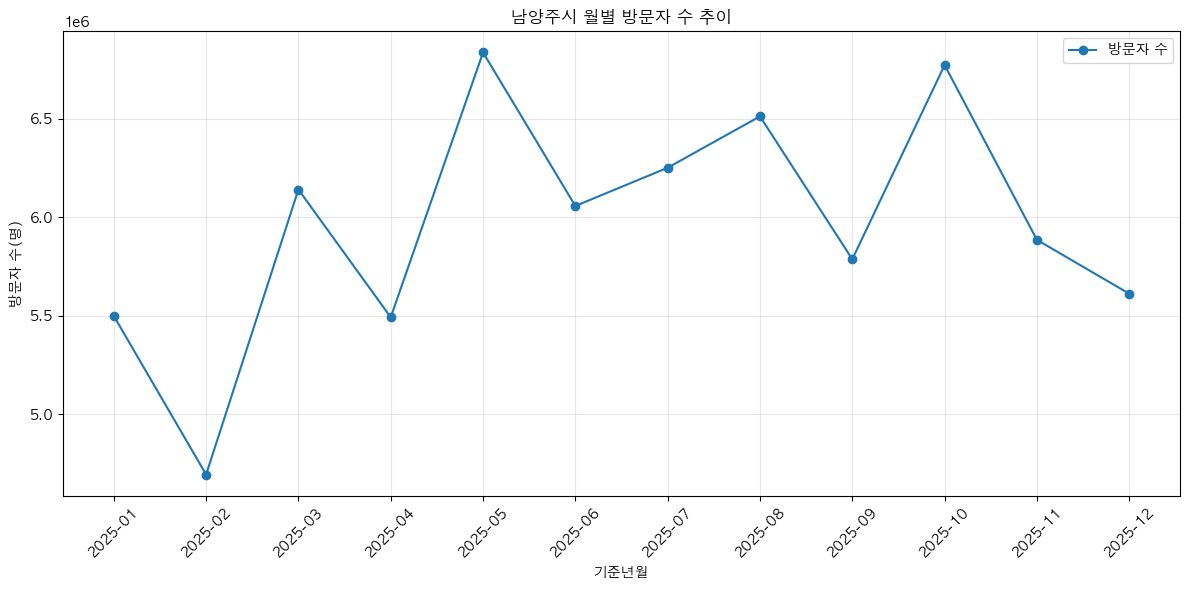

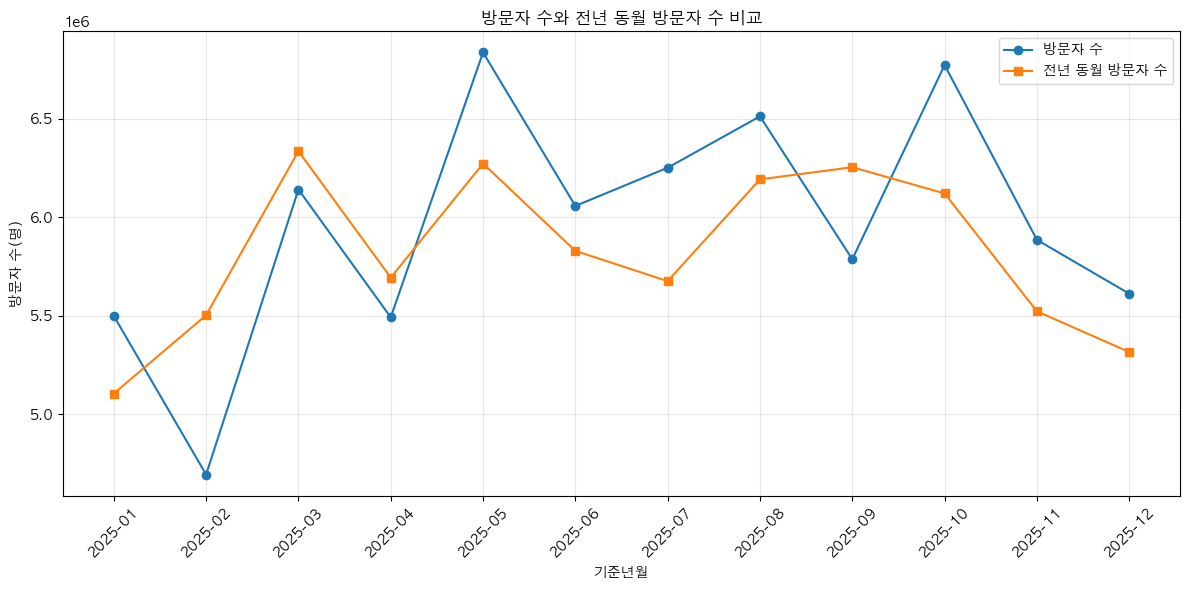

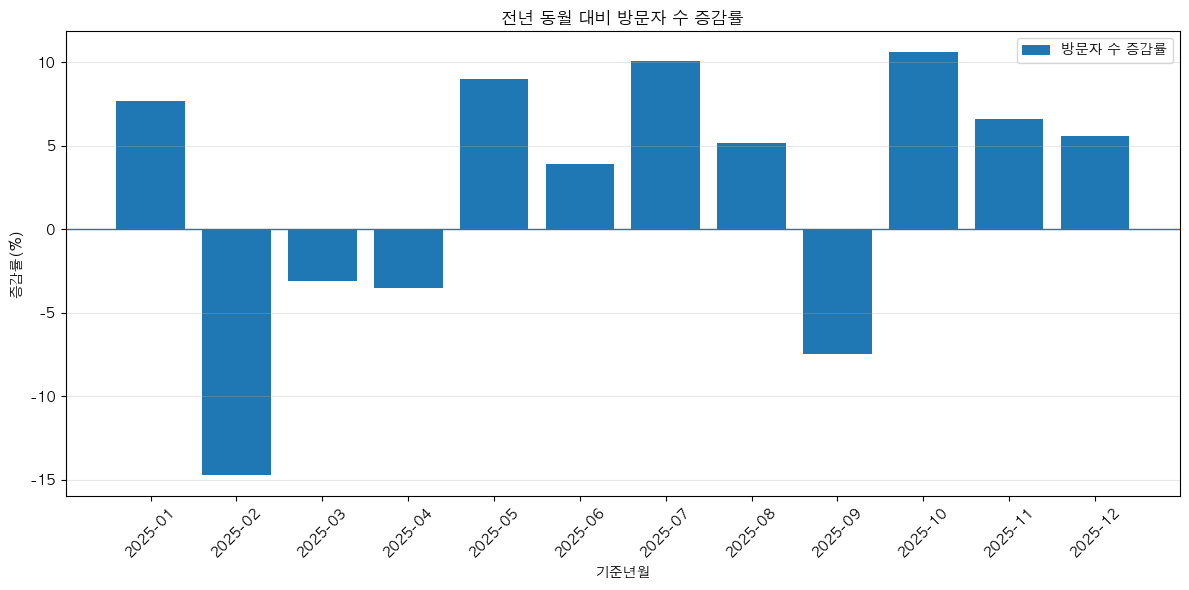

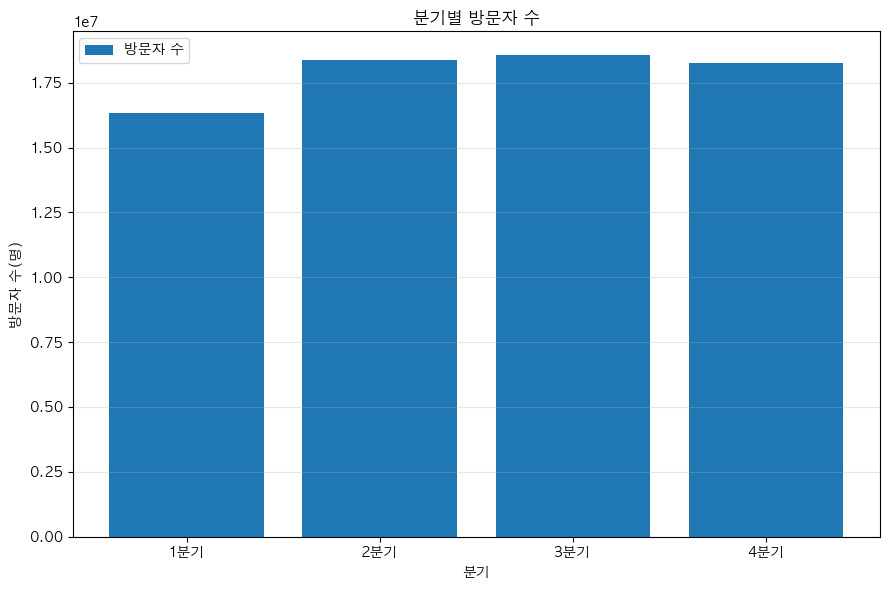

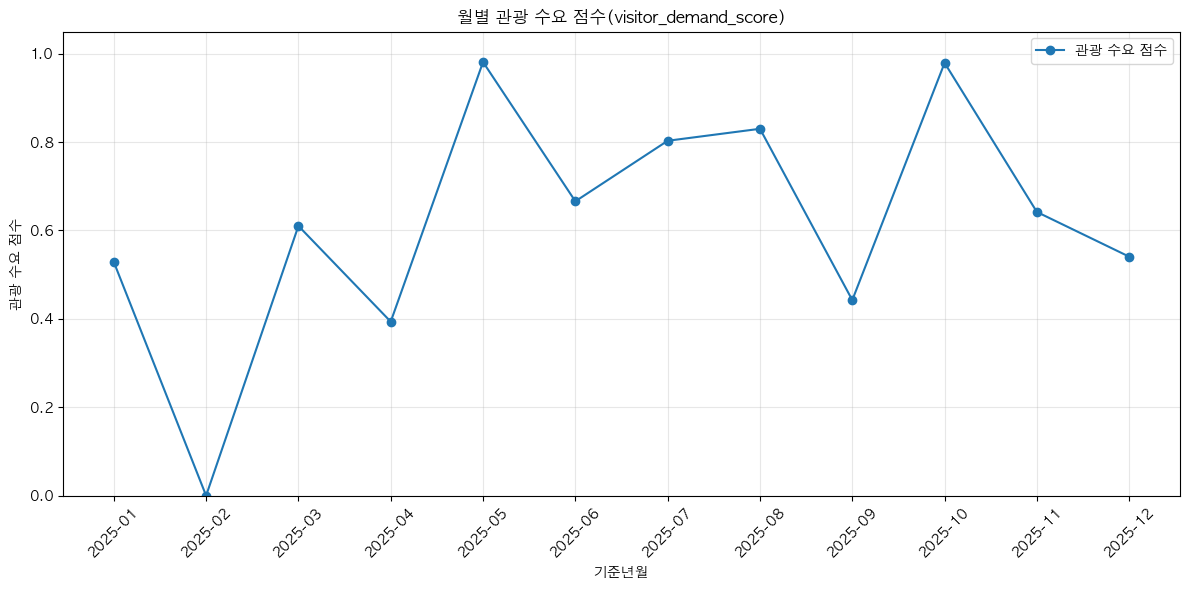

In [9]:
output_dir = Path("./statistics_outputs/남양주시 관광 수요 규모 반영")
output_dir.mkdir(parents=True, exist_ok=True)

# 1) 월별 방문자 수 추이
plt.figure(figsize=(12, 6))
plt.plot(namyangju_tourism_demand_scale['year_month'], namyangju_tourism_demand_scale['방문자수'], marker='o', label='방문자 수')
plt.title('남양주시 월별 방문자 수 추이')
plt.xlabel('기준년월')
plt.ylabel('방문자 수(명)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / '01_monthly_visitor_count.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) 방문자 수와 전년 동월 방문자 수 비교
plt.figure(figsize=(12, 6))
plt.plot(namyangju_tourism_demand_scale['year_month'], namyangju_tourism_demand_scale['방문자수'], marker='o', label='방문자 수')
plt.plot(namyangju_tourism_demand_scale['year_month'], namyangju_tourism_demand_scale['전년동월방문자수'], marker='s', label='전년 동월 방문자 수')
plt.title('방문자 수와 전년 동월 방문자 수 비교')
plt.xlabel('기준년월')
plt.ylabel('방문자 수(명)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / '02_visitor_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3) 전년 동월 대비 방문자 수 증감률
plt.figure(figsize=(12, 6))
plt.bar(namyangju_tourism_demand_scale['year_month'], namyangju_tourism_demand_scale['방문자수증감률'], label='방문자 수 증감률')
plt.axhline(0, linewidth=1)
plt.title('전년 동월 대비 방문자 수 증감률')
plt.xlabel('기준년월')
plt.ylabel('증감률(%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / '03_visitor_growth_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) 분기별 방문자 수
plt.figure(figsize=(9, 6))
plt.bar(quarter_df['분기'], quarter_df['방문자수'], label='방문자 수')
plt.title('분기별 방문자 수')
plt.xlabel('분기')
plt.ylabel('방문자 수(명)')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / '04_quarterly_visitor_count.png', dpi=300, bbox_inches='tight')
plt.show()

# 5) 월별 관광 수요 점수 시각화
plt.figure(figsize=(12, 6))
plt.plot(model_feature_df['year_month'], model_feature_df['visitor_demand_score'], marker='o', label='관광 수요 점수')
plt.title('월별 관광 수요 점수(visitor_demand_score)')
plt.xlabel('기준년월')
plt.ylabel('관광 수요 점수')
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / '05_monthly_tourism_demand_score.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
feature_save_path = output_dir / "visitor_trend_features.csv"

model_feature_df.to_csv(
    feature_save_path,
    index=False,
    encoding="utf-8-sig"
)

print("모델용 파생변수 저장 완료:", feature_save_path)

모델용 파생변수 저장 완료: statistics_outputs/남양주시 관광 수요 규모 반영/visitor_trend_features.csv


### 최근 관광 수요 상승/하락 반영

방문자 증감률 데이터는 남양주시의 관광 수요가 전년 동월 대비 상승하고 있는지 또는 하락하고 있는지를 파악하기 위해 사용한다.  
단순 방문자 수는 관광 수요의 절대 규모를 보여주는 반면, 방문자 수 증감률은 최근 관광 수요의 변화 방향을 보여준다.

따라서 본 분석에서는 `방문자수증감률`을 중심으로 월별 상승·하락 여부를 구분하고, 최근 관광 수요가 증가한 시기와 감소한 시기를 확인한다.  
이를 통해 추천 점수 예측 모델에서 최근 수요가 상승하는 월에는 추천 점수를 보정하고, 수요가 하락하는 월에는 상대적으로 낮은 수요 흐름을 반영할 수 있도록 한다.

#### 분석 진행 방식

1. 데이터 수집
2. 데이터 전처리
   1. 기준년월 전처리
   2. 연도, 월, 분기 컬럼 생성
   3. 방문자 증감 인원 계산
   4. 상승/하락/보합 구분 컬럼 생성
3. 데이터 분석
   1. 월별 방문자 수 증감률 분석
   2. 상승 월과 하락 월 구분
   3. 증감률이 가장 높은 월과 낮은 월 확인
   4. 분기별 평균 증감률 분석
4. 데이터 시각화
   1. 월별 방문자 수 증감률 선그래프
   2. 월별 방문자 수 증감률 막대그래프
   3. 상승/하락 월 개수 막대그래프
   4. 분기별 평균 증감률 막대그래프
5. 모델용 파생변수 생성
   1. `growth_rate_scaled`
   2. `demand_trend_score`
   3. `is_growth_month`
   4. `is_decline_month`

#### 분석 결과 해석

방문자 수 증감률 분석 결과, 2025년 남양주시 방문자 수는 전년 동월 대비 평균 약 2.49% 증가한 것으로 나타났다. 전체 12개월 중 방문자 수가 증가한 달은 8개월, 감소한 달은 4개월로 나타나 전반적으로는 상승 흐름이 우세하다.

가장 높은 증감률을 보인 월은 2025년 10월로, 전년 동월 대비 10.6% 증가하였다. 반면 가장 낮은 증감률을 보인 월은 2025년 2월로, 전년 동월 대비 14.7% 감소하였다. 이를 통해 월별 관광 수요 변화에는 뚜렷한 차이가 있으며, 특정 월에는 전년 대비 관광 수요가 크게 확대되거나 축소되는 경향이 나타난다.

분기별 평균 증감률을 확인하면 1분기는 음의 증감률을 보여 전년 대비 관광 수요가 감소한 반면, 2분기 이후에는 양의 증감률을 보이며 회복 또는 상승 흐름을 보인다. 특히 4분기는 평균 증감률이 가장 높게 나타나 최근 관광 수요 상승세가 강한 시기로 해석할 수 있다.

#### 모델 반영 방향

방문자 수 증감률 데이터는 모델 2의 추천 점수 예측 과정에서 최근 관광 수요의 상승 또는 하락 흐름을 반영하는 변수로 활용한다. 방문자 수가 관광 수요의 절대 규모를 나타낸다면, 방문자 수 증감률은 전년 동월 대비 관광 수요가 얼마나 증가하거나 감소했는지를 나타낸다.

본 분석에서는 방문자 수 증감률을 0~1 범위로 정규화하여 `growth_rate_scaled`를 생성하고, 이를 기반으로 `demand_trend_score`를 구성하였다. 이 점수는 최근 관광 수요 변화 방향을 나타내며, 증감률이 높은 월일수록 추천 점수에 긍정적인 보정값을 줄 수 있다.

최종적으로 모델 2에서는 `demand_trend_score`, `is_growth_month`, `is_decline_month`를 활용하여 최근 관광 수요가 상승하는 시기와 하락하는 시기를 구분하고, 추천 점수 예측 과정에서 월별 수요 변화 흐름을 반영한다.

#### 데이터 시각화 결과

##### 1. 월별 방문자 수 증감률 추이
<img src="./statistics_outputs/최근 관광 수요 상승하락 반영/01_monthly_growth_rate_line.png" width="700">

##### 2. 월별 방문자 수 증감률
<img src="./statistics_outputs/최근 관광 수요 상승하락 반영/02_monthly_growth_rate_bar.png" width="700">

##### 3. 상승/하락 월 개수
<img src="./statistics_outputs/최근 관광 수요 상승하락 반영/03_growth_decline_month_count.png" width="600">

##### 4. 분기별 평균 방문자 수 증감률
<img src="./statistics_outputs/최근 관광 수요 상승하락 반영/04_quarterly_average_growth_rate.png" width="600">

In [18]:
data_path = Path("../Data/recommend_score/20260602152817_방문자 수(연인원) 추이.csv")
visitor_growth_df = pd.read_csv(data_path)

display(visitor_growth_df.head())

,기준년월,방문자수,전년동월방문자수,방문자수증감률
0,202501,5498815.0,5104925.0,7.7
1,202502,4693626.0,5502525.0,-14.7
2,202503,6140508.0,6335304.0,-3.1
3,202504,5492018.0,5693233.0,-3.5
4,202505,6836344.0,6272192.0,9.0


In [22]:
# 기준년월 전처리 및 파생 컬럼 생성
visitor_growth_df["기준년월"] = visitor_growth_df["기준년월"].astype(str)

visitor_growth_df["year"] = visitor_growth_df["기준년월"].str[:4].astype(int)
visitor_growth_df["month"] = visitor_growth_df["기준년월"].str[4:6].astype(int)
visitor_growth_df["quarter"] = ((visitor_growth_df["month"] - 1) // 3) + 1
visitor_growth_df["year_month"] = (
    visitor_growth_df["year"].astype(str) + "-" +
    visitor_growth_df["month"].astype(str).str.zfill(2)
)

# 전년 동월 대비 방문자 증감 인원
visitor_growth_df["visitor_change_count"] = (
    visitor_growth_df["방문자수"] - visitor_growth_df["전년동월방문자수"]
)

# 상승/하락/보합 구분
visitor_growth_df["demand_change_type"] = np.where(
    visitor_growth_df["방문자수증감률"] > 0, "상승",
    np.where(visitor_growth_df["방문자수증감률"] < 0, "하락", "보합")
)

# 모델용 이진 변수
visitor_growth_df["is_growth_month"] = (
    visitor_growth_df["방문자수증감률"] > 0
).astype(int)

visitor_growth_df["is_decline_month"] = (
    visitor_growth_df["방문자수증감률"] < 0
).astype(int)

# 방문자 증감률 기본 통계 분석
growth_summary_df = pd.DataFrame({
    "항목": [
        "평균 증감률",
        "최대 증감률",
        "최소 증감률",
        "상승 월 수",
        "하락 월 수",
        "보합 월 수",
        "최대 상승 월",
        "최대 하락 월"
    ],
    "값": [
        round(visitor_growth_df["방문자수증감률"].mean(), 2),
        round(visitor_growth_df["방문자수증감률"].max(), 2),
        round(visitor_growth_df["방문자수증감률"].min(), 2),
        int((visitor_growth_df["방문자수증감률"] > 0).sum()),
        int((visitor_growth_df["방문자수증감률"] < 0).sum()),
        int((visitor_growth_df["방문자수증감률"] == 0).sum()),
        visitor_growth_df.loc[
            visitor_growth_df["방문자수증감률"].idxmax(), "year_month"
        ],
        visitor_growth_df.loc[
            visitor_growth_df["방문자수증감률"].idxmin(), "year_month"
        ]
    ]
})

# 분기별 평균 증감률 분석

quarter_growth_df = (
    visitor_growth_df
    .groupby("quarter", as_index=False)
    .agg(
        평균증감률=("방문자수증감률", "mean"),
        평균방문자증감인원=("visitor_change_count", "mean"),
        상승월수=("is_growth_month", "sum"),
        하락월수=("is_decline_month", "sum")
    )
)

quarter_growth_df["평균증감률"] = quarter_growth_df["평균증감률"].round(2)
quarter_growth_df["평균방문자증감인원"] = quarter_growth_df["평균방문자증감인원"].round(0).astype(int)

# 모델용 파생변수 생성

scaler = MinMaxScaler()

visitor_growth_df[["growth_rate_scaled"]] = scaler.fit_transform(
    visitor_growth_df[["방문자수증감률"]]
)

# 최근 관광 수요 변화 점수
# 증감률이 높을수록 1에 가까워지고, 낮을수록 0에 가까워짐
visitor_growth_df["demand_trend_score"] = visitor_growth_df["growth_rate_scaled"]

growth_feature_df = visitor_growth_df[
    [
        "year_month",
        "year",
        "month",
        "quarter",
        "방문자수",
        "전년동월방문자수",
        "방문자수증감률",
        "visitor_change_count",
        "demand_change_type",
        "growth_rate_scaled",
        "demand_trend_score",
        "is_growth_month",
        "is_decline_month"
    ]
].copy()

print("방문자 수 증감률 요약")
display(growth_summary_df)

print("방문자 수 증감 데이터")
display(visitor_growth_df)

print("분기별 평균 증감률 분석")
display(quarter_growth_df)

print("모델용 파생변수")
display(growth_feature_df)

방문자 수 증감률 요약


,항목,값
0,평균 증감률,2.49
1,최대 증감률,10.6
2,최소 증감률,-14.7
3,상승 월 수,8
4,하락 월 수,4
5,보합 월 수,0
6,최대 상승 월,2025-10
7,최대 하락 월,2025-02


방문자 수 증감 데이터


,기준년월,방문자수,전년동월방문자수,방문자수증감률,year,month,quarter,year_month,visitor_change_count,demand_change_type,is_growth_month,is_decline_month,growth_rate_scaled,demand_trend_score
0,202501,5498815.0,5104925.0,7.7,2025,1,1,2025-01,393890.0,상승,1,0,0.885375,0.885375
1,202502,4693626.0,5502525.0,-14.7,2025,2,1,2025-02,-808899.0,하락,0,1,0.000000,0.000000
2,202503,6140508.0,6335304.0,-3.1,2025,3,1,2025-03,-194796.0,하락,0,1,0.458498,0.458498
3,202504,5492018.0,5693233.0,-3.5,2025,4,2,2025-04,-201215.0,하락,0,1,0.442688,0.442688
4,202505,6836344.0,6272192.0,9.0,2025,5,2,2025-05,564152.0,상승,1,0,0.936759,0.936759
5,202506,6057026.0,5828952.0,3.9,2025,6,2,2025-06,228074.0,상승,1,0,0.735178,0.735178
6,202507,6251140.0,5675488.0,10.1,2025,7,3,2025-07,575652.0,상승,1,0,0.980237,0.980237
7,202508,6511967.0,6191990.0,5.2,2025,8,3,2025-08,319977.0,상승,1,0,0.786561,0.786561
8,202509,5786554.0,6253712.0,-7.5,2025,9,3,2025-09,-467158.0,하락,0,1,0.284585,0.284585
9,202510,6772346.0,6120604.0,10.6,2025,10,4,2025-10,651742.0,상승,1,0,1.000000,1.000000


분기별 평균 증감률 분석


,quarter,평균증감률,평균방문자증감인원,상승월수,하락월수
0,1,-3.37,-203268,1,2
1,2,3.13,197004,2,1
2,3,2.60,142824,2,1
3,4,7.60,436921,3,0


모델용 파생변수


,year_month,year,month,quarter,방문자수,전년동월방문자수,방문자수증감률,visitor_change_count,demand_change_type,growth_rate_scaled,demand_trend_score,is_growth_month,is_decline_month
0,2025-01,2025,1,1,5498815.0,5104925.0,7.7,393890.0,상승,0.885375,0.885375,1,0
1,2025-02,2025,2,1,4693626.0,5502525.0,-14.7,-808899.0,하락,0.000000,0.000000,0,1
2,2025-03,2025,3,1,6140508.0,6335304.0,-3.1,-194796.0,하락,0.458498,0.458498,0,1
3,2025-04,2025,4,2,5492018.0,5693233.0,-3.5,-201215.0,하락,0.442688,0.442688,0,1
4,2025-05,2025,5,2,6836344.0,6272192.0,9.0,564152.0,상승,0.936759,0.936759,1,0
5,2025-06,2025,6,2,6057026.0,5828952.0,3.9,228074.0,상승,0.735178,0.735178,1,0
6,2025-07,2025,7,3,6251140.0,5675488.0,10.1,575652.0,상승,0.980237,0.980237,1,0
7,2025-08,2025,8,3,6511967.0,6191990.0,5.2,319977.0,상승,0.786561,0.786561,1,0
8,2025-09,2025,9,3,5786554.0,6253712.0,-7.5,-467158.0,하락,0.284585,0.284585,0,1
9,2025-10,2025,10,4,6772346.0,6120604.0,10.6,651742.0,상승,1.000000,1.000000,1,0


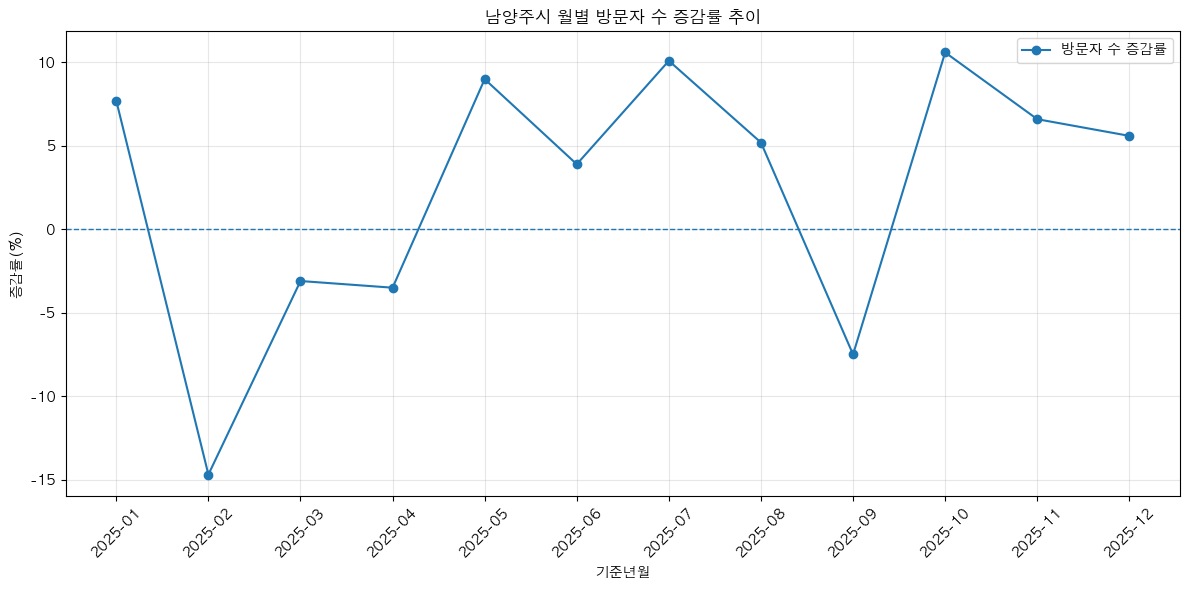

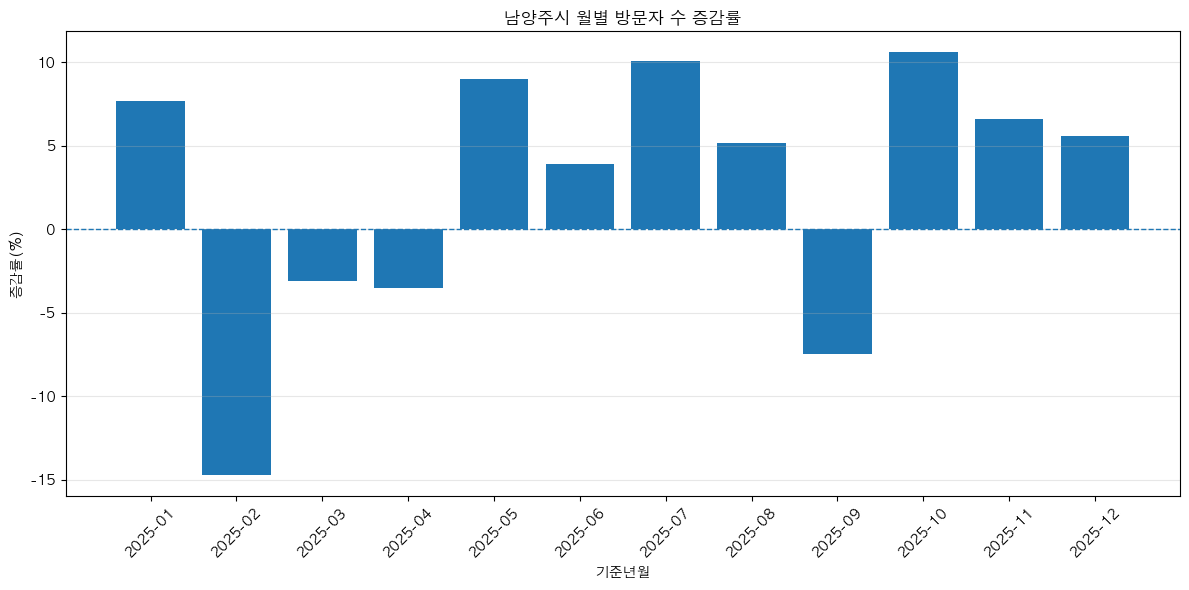

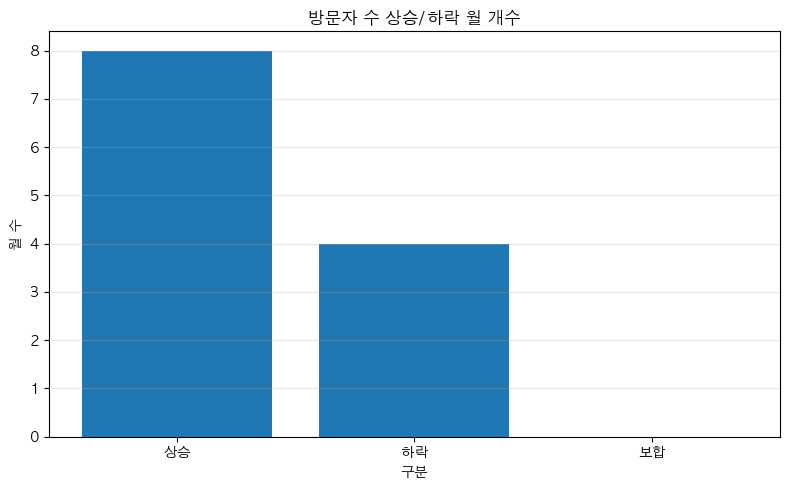

,구분,월수
0,상승,8.0
1,하락,4.0
2,보합,0.0


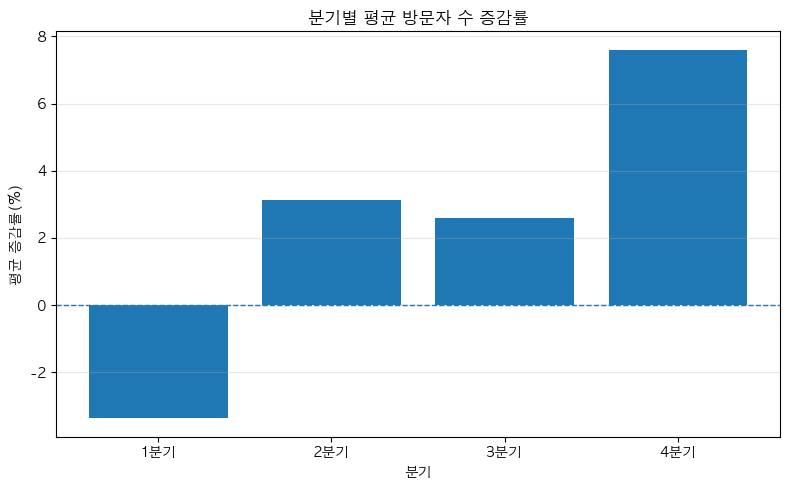

In [23]:
# 시각화 결과 저장 폴더 생성
output_dir = Path("./statistics_outputs/최근 관광 수요 상승하락 반영")
output_dir.mkdir(parents=True, exist_ok=True)

# 1) 월별 방문자 수 증감률 선그래프
plt.figure(figsize=(12, 6))
plt.plot(
    visitor_growth_df["year_month"],
    visitor_growth_df["방문자수증감률"],
    marker="o",
    label="방문자 수 증감률"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("남양주시 월별 방문자 수 증감률 추이")
plt.xlabel("기준년월")
plt.ylabel("증감률(%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "01_monthly_growth_rate_line.png", dpi=300, bbox_inches="tight")
plt.show()

# 2) 월별 방문자 수 증감률 막대그래프
plt.figure(figsize=(12, 6))
plt.bar(
    visitor_growth_df["year_month"],
    visitor_growth_df["방문자수증감률"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("남양주시 월별 방문자 수 증감률")
plt.xlabel("기준년월")
plt.ylabel("증감률(%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "02_monthly_growth_rate_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# 3) 상승/하락 월 개수 막대그래프
change_type_count_df = (
    visitor_growth_df["demand_change_type"]
    .value_counts()
    .reindex(["상승", "하락", "보합"])
    .fillna(0)
    .reset_index()
)
change_type_count_df.columns = ["구분", "월수"]
plt.figure(figsize=(8, 5))
plt.bar(
    change_type_count_df["구분"],
    change_type_count_df["월수"]
)
plt.title("방문자 수 상승/하락 월 개수")
plt.xlabel("구분")
plt.ylabel("월 수")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "03_growth_decline_month_count.png", dpi=300, bbox_inches="tight")
plt.show()
display(change_type_count_df)

# 4) 분기별 평균 증감률 막대그래프
plt.figure(figsize=(8, 5))
plt.bar(
    quarter_growth_df["quarter"].astype(str) + "분기",
    quarter_growth_df["평균증감률"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("분기별 평균 방문자 수 증감률")
plt.xlabel("분기")
plt.ylabel("평균 증감률(%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "04_quarterly_average_growth_rate.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# 모델용 파생변수 저장
feature_save_path = output_dir / "visitor_growth_features.csv"

growth_feature_df.to_csv(
    feature_save_path,
    index=False,
    encoding="utf-8-sig"
)

print("모델용 파생변수 저장 완료:", feature_save_path)

모델용 파생변수 저장 완료: statistics_outputs/최근 관광 수요 상승하락 반영/visitor_growth_features.csv
